In [ ]:
import os
import sys
import pickle
import pandas as pd
import kagglehub
import xgboost as xgb
from sklearn.preprocessing import RobustScaler

os.environ["LOG_LEVEL"] = "DEBUG"

# Adds the parent directory to sys.path
sys.path.append("..")

from models.unbalanced_clustering import UnbalancedClustering

/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Fetch dataset from Kaggle
csv_file = "creditcard.csv"
path = kagglehub.dataset_download(
    "mlg-ulb/creditcardfraud",
    path=csv_file,
    output_dir="../datasets"
    )
full_path = f"../datasets/{csv_file}"
df = pd.read_csv(full_path, engine="python")
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [3]:
# These look like PCA columns, V-columns likely already scaled
# "Amount" likely not scaled - XGBoost doesn't require scaling, but other approaches (regression, KNN, NN) do
# "Time" as given (seconds since first transaction) likely useless, more worthwhile to transform

# Inspect Amount to decide on a scaler 
df["Amount"].describe()  # std = 250 is very high, we have some extreme outliers

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

In [ ]:
# Since we have extreme outliers, going to use Robust Scaler (subtract median, divide by IQR)
# XGBoost doesn't care about scale, but other methods I might try (KNN, NN, Regression) will care.
scaler = RobustScaler()
df["Amount"] = scaler.fit_transform(df[["Amount"]])

# Save scaler
with open('../models/resources/fraud_detection_with_xgboost_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

In [5]:
# Check the Class Balance for Weights
counts = df["Class"].value_counts()
imbalance = counts[0] / counts[1]
print(f"Total Fraud: {counts[1]}")
print(f"Total Legit: {counts[0]}")
print(f"Recommended scale_pos_weight: {imbalance:.2f}")

Total Fraud: 492
Total Legit: 284315
Recommended scale_pos_weight: 577.88


In [6]:
# Handle time column
df['TimeOfDay'] = (df['Time'] / 3600) % 24
df = df.drop(columns=['Time'])
df

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,TimeOfDay
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,1.783274,0,0.000000
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.269825,0,0.000000
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,4.983721,0,0.000278
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,1.418291,0,0.000278
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0.670579,0,0.000556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,...,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,-0.296653,0,23.996111
284803,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,...,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,0.038986,0,23.996389
284804,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,...,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,0.641096,0,23.996667
284805,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,...,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,-0.167680,0,23.996667


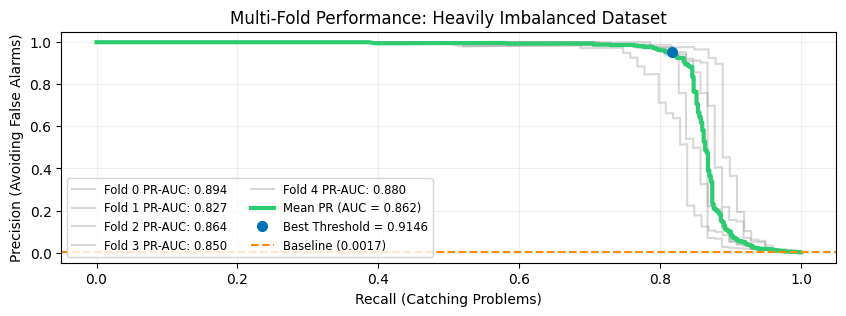

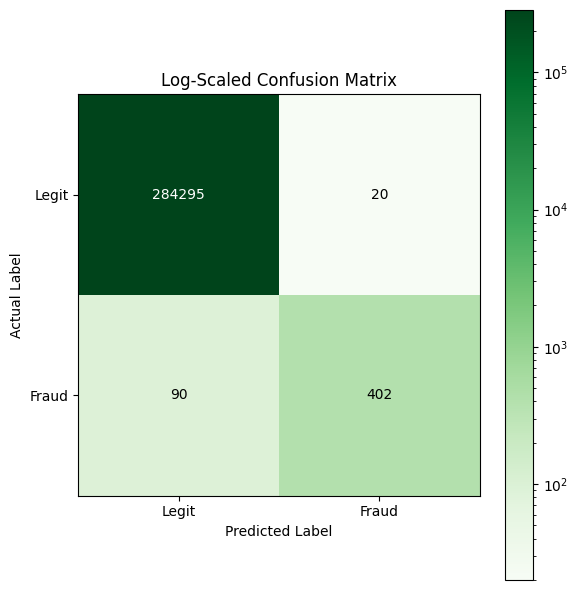

In [8]:
# Set up X and y data
features = [col for col in df.columns if col != "Class"]
X = df[features].values
y = df[["Class"]].values

uc = UnbalancedClustering(X, y, n_splits=5, features=features, show_fig=True)
y_final_predictions, cm, metrics, sorted_importances, fig1, fig2 = uc.run_training()

In [10]:
# Testing a new sample with the trained model

# Load the saved model
model = xgb.Booster()
model.load_model('../models/resources/credit_fraud_model.json')

In [11]:
# Get a single sample from the test set
sample_transaction = uc.X_test[0:1]  # Use [0:1] to keep it as a 2D array (1 row, N features)
actual_label = uc.y_test[0]

# Convert to DMatrix for native xgboost
d_sample = xgb.DMatrix(sample_transaction)

# Predict the probability of the sample
prob = model.predict(d_sample)

# Compare against trained Optimal Threshold
is_fraud = prob >= metrics["best_threshold"]

print(f"*** Transaction Analysis ***")
print(f"Fraud Probability: {prob[0]:.6f}")
print(f"Action: {'DECLINE (Fraud Detected)' if is_fraud else 'APPROVE (Legit)'}")
print(f"Actual Label: {'Fraud' if actual_label == 1 else 'Legit'}")

*** Transaction Analysis ***
Fraud Probability: 0.000000
Action: APPROVE (Legit)
Actual Label: Legit


In [ ]:
Transaction(
    V1=-4.771948,
    V2=3.623778,
    V3=-7.033281,
    V4=4.542029,
    V5=-3.151225,
    V6=-1.397737,
    V7=-5.568731,
    V8=0.570636,
    V9=-2.581123,
    V10=-5.676883,
    V11=3.800173,
    V12=-6.259393,
    V13=-0.109334,
    V14=-6.971723,
    V15=-0.092929,
    V16=-4.139946,
    V17=-6.665836,
    V18=-2.246308,
    V19=0.680659,
    V20=0.372319,
    V21=0.713588,
    V22=0.014049,
    V23=-0.040308,
    V24=-0.105130,
    V25=0.041449,
    V26=0.051648,
    V27=0.170575,
    V28=0.075667,
    Amount=1.400284,
    TimeOfDay=12.136986,
    )